# E-Commerce Purchase Prediction — Neural Network with PyTorch

## Business Problem

**ShopSmart** is a fast-growing international e-commerce platform operating across Europe, North America and Asia. They sell Fashion, Electronics and Home Goods.

The marketing team wants to answer one question:

> **"Which customers are most likely to make a purchase based on their browsing behaviour?"**

By predicting purchase intent, ShopSmart can:
- Show targeted promotions only to likely buyers
- Reduce wasted marketing spend
- Increase conversion rate and revenue

---
`

---

## Dataset Description

| Column | Type | Description |
|---|---|---|
| customer_id | Integer | Unique identifier |
| age | Integer | Customer age |
| time_spent | Float | Minutes on website per session |
| pages_viewed | Integer | Pages viewed per session |
| basket_value | Float | Value of items in basket |
| device_type | String | Mobile, Desktop, Tablet |
| customer_type | String | New, Returning |
| category | String | Fashion, Electronics, Home Goods |
| num_sessions | Integer | Number of sessions |
| purchase | Binary | 1 = bought, 0 = did not buy |

---

## Step 0 — Import Libraries

In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
from matplotlib.patches import Patch
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import sys
import os
sys.path.insert(0, os.path.abspath(os.path.join(os.getcwd(), '..', 'src')))
from model import PurchaseNet, train_model, predict


# Reproducibility
np.random.seed(42)
torch.manual_seed(42)

print('All libraries imported successfully')

All libraries imported successfully


---

## Step 1 — Load and Inspect Raw Data

Before touching any data, a data scientist always inspects it first.
We want to understand:
- How many rows and columns
- What data types each column has
- How many missing values exist
- What the data looks like

In [11]:
df = pd.read_csv('../data/raw_customer_data.csv')

print('=== Shape (rows, columns) ===')
print(df.shape)

print('\n=== First 5 rows ===')
print(df.head())

print('\n=== Data types and non-null counts ===')
print(df.info())

=== Shape (rows, columns) ===
(5000, 10)

=== First 5 rows ===
   customer_id  age  time_spent  pages_viewed  basket_value device_type  \
0            1   56       94.80          16.0         59.43      Mobile   
1            2   69       15.28          20.0         20.80     Desktop   
2            3   46       54.94          29.0         10.37      Mobile   
3            4   32        6.27           6.0         36.13      Mobile   
4            5   60       33.48          26.0         23.60      Mobile   

  customer_type     category  num_sessions  purchase  
0     Returning      Fashion            16         1  
1     Returning  Electronics            11         0  
2     Returning  Electronics             4         0  
3     Returning   Home Goods             9         1  
4     Returning      Fashion            15         1  

=== Data types and non-null counts ===
<class 'pandas.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 10 columns):
 #   Column         

In [12]:
print('=== Missing values per column ===')

missing  = df.isnull().sum()
missing_pct = (df.isnull().sum() / len(df)* 100). round(2)

missing_df = pd.DataFrame({
    'Missing Count' : missing,
    'Missing %' : missing_pct
})

print(missing_df)

print('\n Statistical summary === ')
print(df.describe()) 

=== Missing values per column ===
               Missing Count  Missing %
customer_id                0        0.0
age                        0        0.0
time_spent               250        5.0
pages_viewed             200        4.0
basket_value             300        6.0
device_type              150        3.0
customer_type            150        3.0
category                   0        0.0
num_sessions               0        0.0
purchase                   0        0.0

 Statistical summary === 
       customer_id          age   time_spent  pages_viewed  basket_value  \
count  5000.000000  5000.000000  4750.000000   4800.000000   4700.000000   
mean   2500.500000    43.584600    29.185949     15.317917     80.530868   
std    1443.520003    14.919094    29.345378      8.260790     81.809987   
min       1.000000    18.000000     0.000000      1.000000      0.010000   
25%    1250.750000    31.000000     8.315000      8.000000     22.647500   
50%    2500.500000    43.000000    19.92000

---
## Step 2 - Visualize the Data

Before cleaning, we visualize the data to understand:
- How purchases are distributed
- Which features are most related to purchase behaviour
- Whether any patterns are visible in the raw data

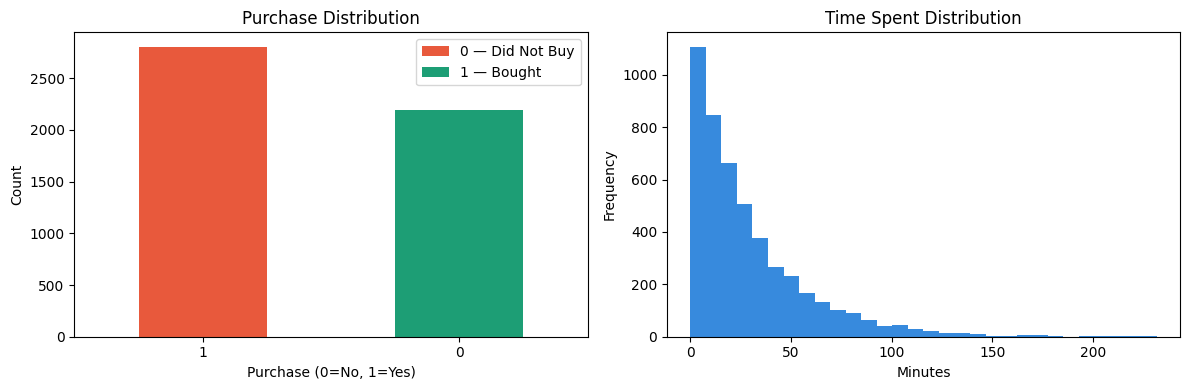

Purchase rate: 56.06%


In [13]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

df['purchase'].value_counts().plot(
    kind = 'bar',
    ax= axes[0],
    color=['#E8593c' ,'#1D9E75']
    
)

axes[0].set_title('Purchase Distribution')
axes[0].set_xlabel('Purchase (0=No, 1=Yes)')
axes[0].set_ylabel('Count')
axes[0].tick_params(rotation=0)
legend_elements = [
    Patch(facecolor='#E8593C', label='0 — Did Not Buy'),
    Patch(facecolor='#1D9E75', label='1 — Bought')
]
axes[0].legend(handles=legend_elements)


#------------------------------

df['time_spent'].dropna().plot(
    kind='hist',
    ax=axes[1],
    bins=30,
    color='#378ADD'
)
axes[1].set_title('Time Spent Distribution')
axes[1].set_xlabel('Minutes')


plt.tight_layout()
plt.show()

print(f"Purchase rate: {df['purchase'].mean():.2%}")

---
## Step 3 — Clean the Data

We handle missing values using the appropriate strategy per column:

| Column | Strategy | Why |
|---|---|---|
| time_spent | Median | Skewed distribution — median is more robust |
| pages_viewed | Mean | Roughly normal — mean is appropriate |
| basket_value | 0 | Missing likely means empty basket |
| device_type | 'Unknown' | Cannot guess device |
| customer_type | 'New' | Safe business assumption |

In [14]:
clean_data = df.copy()

clean_data['time_spent']    = clean_data['time_spent'].fillna(clean_data['time_spent'].median())
clean_data['pages_viewed']  = clean_data['pages_viewed'].fillna(clean_data['pages_viewed'].mean()).round().astype(int)
clean_data['basket_value']  = clean_data['basket_value'].fillna(0)
clean_data['device_type']   = clean_data['device_type'].fillna('Unknown')
clean_data['customer_type'] = clean_data['customer_type'].fillna('New')

clean_data['device_type']   = clean_data['device_type'].astype(str)
clean_data['customer_type'] = clean_data['customer_type'].astype(str)
clean_data['category']      = clean_data['category'].astype(str)

print('=== Missing values after cleaning ===')
print(clean_data.isnull().sum())

print('\n=== Data types after cleaning ===')
print(clean_data.dtypes)

clean_data.to_csv('../data/clean_data.csv', index=False)
print('\nClean data saved!')


=== Missing values after cleaning ===
customer_id      0
age              0
time_spent       0
pages_viewed     0
basket_value     0
device_type      0
customer_type    0
category         0
num_sessions     0
purchase         0
dtype: int64

=== Data types after cleaning ===
customer_id        int64
age                int64
time_spent       float64
pages_viewed       int64
basket_value     float64
device_type          str
customer_type        str
category             str
num_sessions       int64
purchase           int64
dtype: object

Clean data saved!


---
## Step 4 — Exploratory Data Analysis (EDA)

Now that data is clean, we explore relationships between 
features and the target variable (purchase).

This helps us understand:
- Which features are most predictive of purchase
- Whether patterns exist in the data
- What the model will likely learn

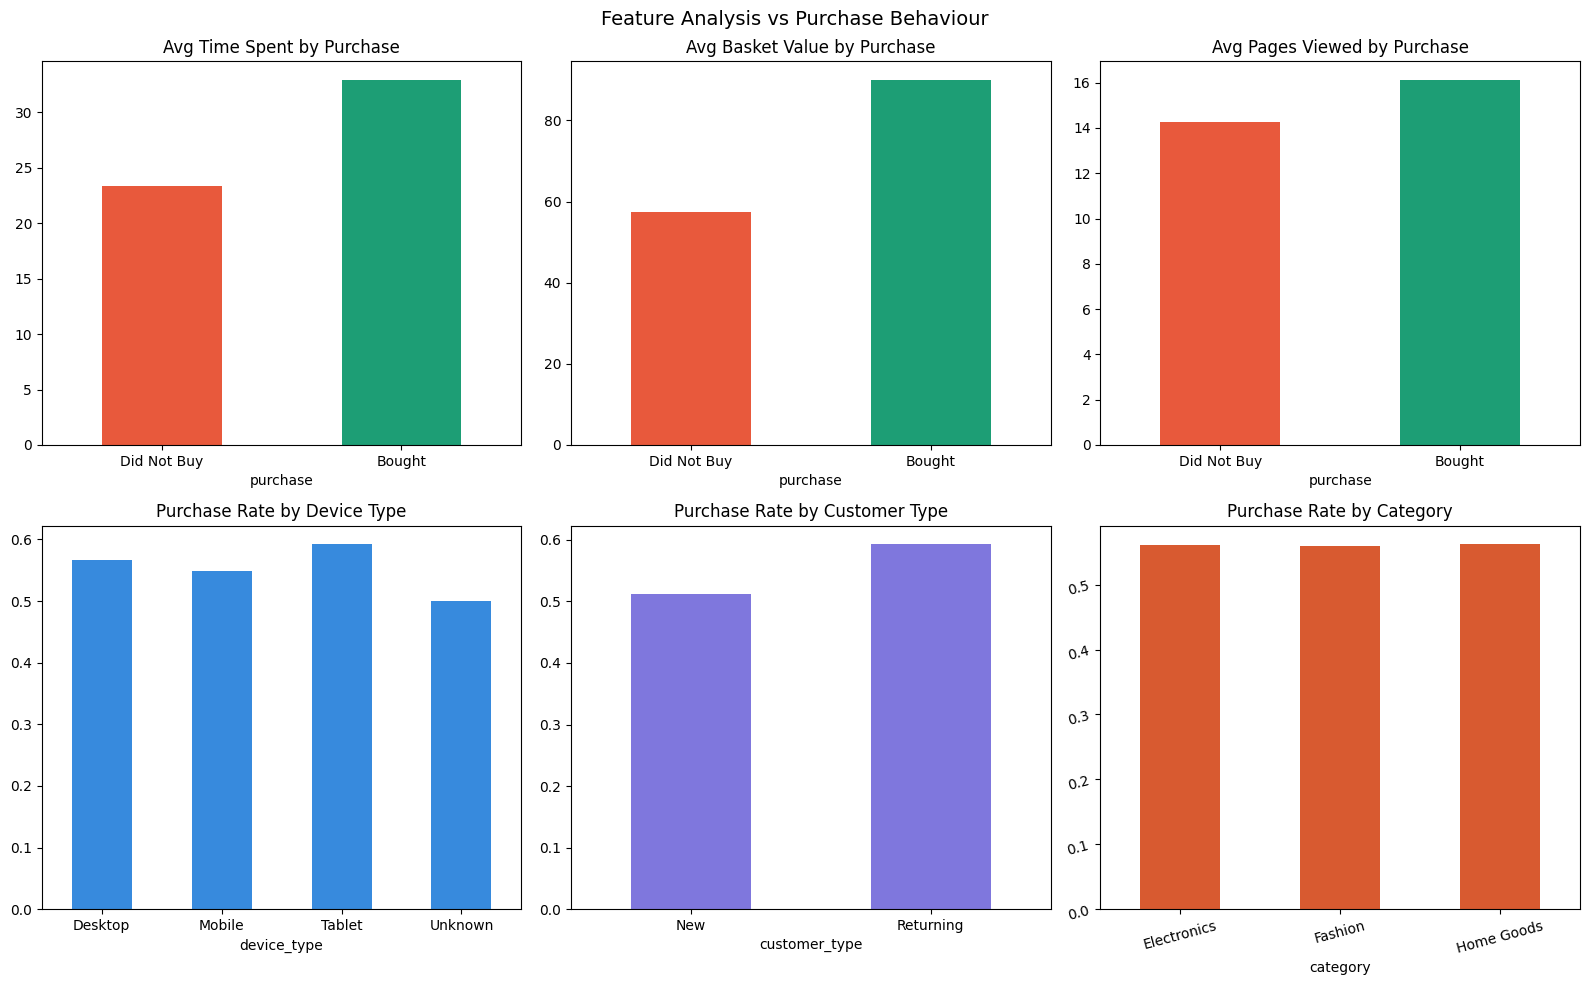

In [15]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))

clean_data.groupby('purchase')['time_spent'].mean().plot(
    kind='bar', ax=axes[0,0], color=['#E8593C','#1D9E75'])
axes[0,0].set_title('Avg Time Spent by Purchase')
axes[0,0].set_xticklabels(['Did Not Buy', 'Bought'], rotation=0)

clean_data.groupby('purchase')['basket_value'].mean().plot(
    kind='bar', ax=axes[0,1], color=['#E8593C','#1D9E75'])
axes[0,1].set_title('Avg Basket Value by Purchase')
axes[0,1].set_xticklabels(['Did Not Buy', 'Bought'], rotation=0)

clean_data.groupby('purchase')['pages_viewed'].mean().plot(
    kind='bar', ax=axes[0,2], color=['#E8593C','#1D9E75'])
axes[0,2].set_title('Avg Pages Viewed by Purchase')
axes[0,2].set_xticklabels(['Did Not Buy', 'Bought'], rotation=0)

clean_data.groupby('device_type')['purchase'].mean().plot(
    kind='bar', ax=axes[1,0], color='#378ADD')
axes[1,0].set_title('Purchase Rate by Device Type')
axes[1,0].tick_params(rotation=0)

clean_data.groupby('customer_type')['purchase'].mean().plot(
    kind='bar', ax=axes[1,1], color='#7F77DD')
axes[1,1].set_title('Purchase Rate by Customer Type')
axes[1,1].tick_params(rotation=0)

clean_data.groupby('category')['purchase'].mean().plot(
    kind='bar', ax=axes[1,2], color='#D85A30')
axes[1,2].set_title('Purchase Rate by Category')
axes[1,2].tick_params(rotation=15)

plt.suptitle('Feature Analysis vs Purchase Behaviour', fontsize=14)
plt.tight_layout()
plt.show()

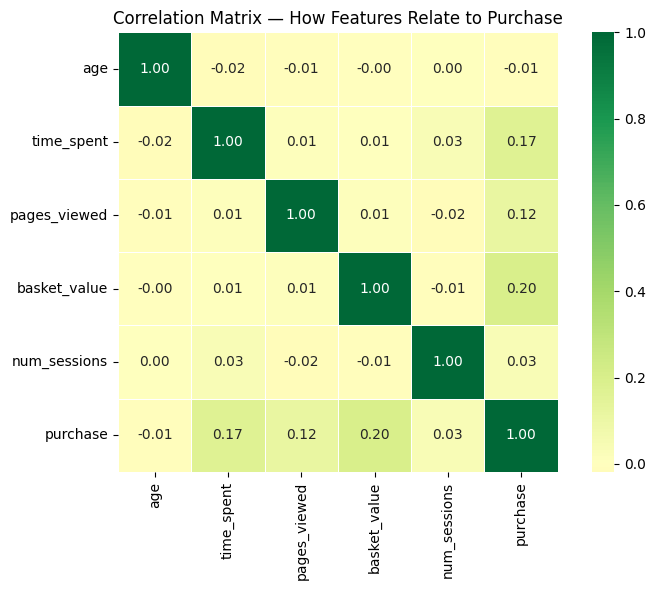

=== Correlation with Purchase ===
purchase        1.000000
basket_value    0.198847
time_spent      0.166815
pages_viewed    0.115989
num_sessions    0.034595
age            -0.010201
Name: purchase, dtype: float64


In [16]:
numeric_cols = ['age', 'time_spent', 'pages_viewed', 'basket_value', 'num_sessions', 'purchase']
corr = clean_data[numeric_cols].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(
    corr,
    annot=True,
    fmt='.2f',
    cmap='RdYlGn',
    center=0,
    square=True,
    linewidths=0.5
)
plt.title('Correlation Matrix — How Features Relate to Purchase')
plt.tight_layout()
plt.show()

print('=== Correlation with Purchase ===')
print(corr['purchase'].sort_values(ascending=False))

---
## Step 5 — Feature Engineering

We prepare the data for the neural network in two steps:

**Step 1 — Scale numeric features to 0-1 range**
Neural networks work best when all numbers are on the same scale.
A column with values 0-500 would dominate a column with values 0-5.

**Step 2 — One-hot encode categorical features**
Neural networks only understand numbers.
Text like 'Mobile' or 'New' must be converted to 0s and 1s.

In [17]:
model_data = clean_data.copy()

# Step 1 — Scale numeric features
scaler          = MinMaxScaler()
numeric_features = ['age', 'time_spent', 'pages_viewed', 'basket_value', 'num_sessions']
model_data[numeric_features] = scaler.fit_transform(model_data[numeric_features])

# Step 2 — One-hot encode categorical features
model_data = pd.get_dummies(
    model_data,
    columns=['device_type', 'customer_type', 'category'],
    prefix=['device_type', 'customer_type', 'category']
)

print('=== Columns after feature engineering ===')
for col in model_data.columns:
    print(f'  {col}')

print(f'\nTotal columns: {len(model_data.columns)}')
print(f'Feature columns: {len(model_data.columns) - 2}')

model_data.to_csv('../data/model_features.csv', index=False)
print('\nModel features saved!')

=== Columns after feature engineering ===
  customer_id
  age
  time_spent
  pages_viewed
  basket_value
  num_sessions
  purchase
  device_type_Desktop
  device_type_Mobile
  device_type_Tablet
  device_type_Unknown
  customer_type_New
  customer_type_Returning
  category_Electronics
  category_Fashion
  category_Home Goods

Total columns: 16
Feature columns: 14

Model features saved!


---
## Step 6 — Split into Train and Validation Sets

We split the data into two sets:

- **Training set (80%)** — the model learns from this data
- **Validation set (20%)** — we test on data the model never saw

Why do we need two sets?
If we test on the same data we trained on, the model looks 
accurate but might just be memorising. The validation set 
proves the model truly learned real patterns.

In [18]:
# Separate features (X) and target (y)
feature_cols = [c for c in model_data.columns if c not in ['customer_id', 'purchase']]

X = model_data[feature_cols]
y = model_data['purchase']

# Split 80% train, 20% validation
X_train, X_val, y_train, y_val = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(f'Total dataset:  {len(X)} customers')
print(f'Training set:   {len(X_train)} customers ({len(X_train)/len(X):.0%})')
print(f'Validation set: {len(X_val)} customers ({len(X_val)/len(X):.0%})')
print(f'\nPurchase rate in training:   {y_train.mean():.2%}')
print(f'Purchase rate in validation: {y_val.mean():.2%}')

# Save both sets
train_df = model_data.loc[X_train.index].reset_index(drop=True)
val_df   = model_data.loc[X_val.index].reset_index(drop=True)

train_df.to_csv('../data/train_features.csv', index=False)
val_df.to_csv('../data/validation_features.csv', index=False)
print('\nTrain and validation sets saved!')

Total dataset:  5000 customers
Training set:   4000 customers (80%)
Validation set: 1000 customers (20%)

Purchase rate in training:   56.05%
Purchase rate in validation: 56.10%

Train and validation sets saved!


## Step 7 — Build the Neural Network

We import our PurchaseNet from model.py and initialize it.

Architecture:
- Input layer: one node per feature
- Hidden layer 1: 16 neurons + ReLU + Dropout(0.2)
- Hidden layer 2: 8 neurons + ReLU
- Output layer: 1 neuron + Sigmoid (outputs probability 0-1)

In [34]:
# Convert data to PyTorch tensors
X_train_t = torch.tensor(X_train.values.astype('float32'))
y_train_t  = torch.tensor(y_train.values.astype('float32')).unsqueeze(1)
X_val_t    = torch.tensor(X_val.values.astype('float32'))
y_val_t    = torch.tensor(y_val.values.astype('float32')).unsqueeze(1)

# Initialize model
input_size     = X_train_t.shape[1]
purchase_model = PurchaseNet(input_size)

# Define loss function and optimizer
criterion = nn.BCELoss()
optimizer = torch.optim.Adam(purchase_model.parameters(), lr=0.001)

print(f'Input size:     {input_size} features')
print(f'Training rows:  {X_train_t.shape[0]} customers')
print(f'Validation rows:{X_val_t.shape[0]} customers')
print(f'\nModel architecture:')
print(purchase_model)

Input size:     14 features
Training rows:  4000 customers
Validation rows:1000 customers

Model architecture:
PurchaseNet(
  (network): Sequential(
    (0): Linear(in_features=14, out_features=16, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.2, inplace=False)
    (3): Linear(in_features=16, out_features=8, bias=True)
    (4): ReLU()
    (5): Linear(in_features=8, out_features=1, bias=True)
    (6): Sigmoid()
  )
)


---
## Step 8 — Train the Model

We train the neural network for 150 epochs.
After each epoch the model adjusts its weights to reduce loss.

We track both training and validation loss to detect overfitting:
- Both going down = model is learning correctly
- Val loss going up while train loss goes down = overfitting

In [35]:
train_losses = []
val_losses   = []
epochs       = 500

for epoch in range(epochs):

    # Training phase
    purchase_model.train()
    optimizer.zero_grad()
    train_output = purchase_model(X_train_t)
    train_loss   = criterion(train_output, y_train_t)
    train_loss.backward()
    optimizer.step()
    train_losses.append(train_loss.item())

    # Validation phase
    purchase_model.eval()
    with torch.no_grad():
        val_output = purchase_model(X_val_t)
        val_loss   = criterion(val_output, y_val_t)
    val_losses.append(val_loss.item())

    if epoch % 50 == 0:
        print(f'Epoch {epoch:3d} | Train Loss: {train_loss.item():.4f} | Val Loss: {val_loss.item():.4f}')

print('\nTraining complete!')

Epoch   0 | Train Loss: 0.7478 | Val Loss: 0.7445
Epoch  50 | Train Loss: 0.7032 | Val Loss: 0.7026
Epoch 100 | Train Loss: 0.6848 | Val Loss: 0.6851
Epoch 150 | Train Loss: 0.6815 | Val Loss: 0.6814
Epoch 200 | Train Loss: 0.6778 | Val Loss: 0.6783
Epoch 250 | Train Loss: 0.6737 | Val Loss: 0.6739
Epoch 300 | Train Loss: 0.6663 | Val Loss: 0.6674
Epoch 350 | Train Loss: 0.6624 | Val Loss: 0.6599
Epoch 400 | Train Loss: 0.6505 | Val Loss: 0.6517
Epoch 450 | Train Loss: 0.6447 | Val Loss: 0.6451

Training complete!


---
## Step 9 — Visualise Training Curves

We plot training and validation loss over all epochs.
This shows us whether the model learned properly or overfit.

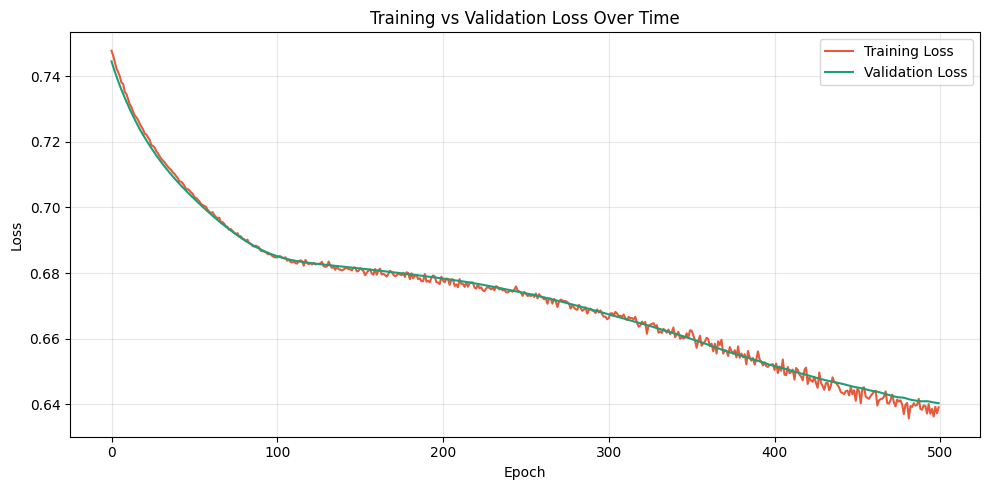

Starting train loss: 0.7478
Final train loss:    0.6391
Starting val loss:   0.7445
Final val loss:      0.6404


In [36]:
plt.figure(figsize=(10, 5))
plt.plot(train_losses, label='Training Loss',   color='#E8593C')
plt.plot(val_losses,   label='Validation Loss', color='#1D9E75')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training vs Validation Loss Over Time')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f'Starting train loss: {train_losses[0]:.4f}')
print(f'Final train loss:    {train_losses[-1]:.4f}')
print(f'Starting val loss:   {val_losses[0]:.4f}')
print(f'Final val loss:      {val_losses[-1]:.4f}')